# Unmasked linear systems: normalized with-self vs no-self

Each state matrix is normalized independently to spectral radius 0.95. Structural paths, finite-horizon controllability, and stable continuous frequency response are then compared using identical settings.

## Notebook role in the analysis sequence

**Role:** Companion to `09_linear_systems.ipynb`.

**Inputs:**
- `matrices/mij_matrix.csv`

**Outputs:**
- `outputs/network_linear_systems/self_comparison/summary.csv`
- `outputs/network_linear_systems/self_comparison/top_path_scores.csv`
- `outputs/network_linear_systems/self_comparison/top_controllability_scores.csv`
- `outputs/network_linear_systems/self_comparison/frequency_curves.csv`

**What this notebook adds:**
- Compares structural paths, controllability, and frequency response with and without self-connections.
- Uses matched independent spectral-radius normalization to `0.95`.
- Tests whether off-diagonal network structure produces stronger path accumulation and transfer gain.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display
from network_linear_systems_tools_script import compare_self_linear_systems

MATRIX_PATH = Path('matrices/mij_matrix.csv')
OUTPUT_DIR = Path('outputs/network_linear_systems/self_comparison')

## Run the matched comparison

In [2]:
comparison = compare_self_linear_systems(
    MATRIX_PATH,
    target_spectral_radius=0.95,
    max_path_length=6,
    gramian_horizon=25,
)
display(comparison['summary'])

,variant,raw_spectral_radius,achieved_spectral_radius,matrix_fro_norm,non_normality,cumulative_path_fro_norm,gramian_trace,gramian_condition,peak_frequency,peak_frequency_gain
0,with_self,26213.130121,0.95,77.182134,5869.903453,131.963304,9546.597885,5767.198603,0.01,69.386541
1,no_self,14837.865933,0.95,136.346623,18319.829226,323.867335,56245.572758,42740.433659,0.01,193.433871


## Path and controllability rankings

In [3]:
display(comparison['top_path_scores'])
display(comparison['top_controllability_scores'])

,variant,cell,outgoing_path_score,incoming_path_score,net_out_minus_in
0,with_self,CA3c Pyramidal,300.702316,1.094099,299.608217
1,with_self,EC LI II Multipolar Pyramidal,291.319707,6.348489,284.971218
2,with_self,CA3 Pyramidal,202.232120,1.354195,200.877925
3,with_self,EC LI II Pyramidal Fan,98.308919,0.775857,97.533062
4,with_self,CA2 Pyramidal,57.910547,5.065881,52.844666
5,with_self,EC LII III Pyramidal Tripolar,57.170432,7.825161,49.345271
6,with_self,MEC LII Stellate,57.140984,6.875329,50.265655
7,with_self,DG Granule,54.270022,2.839643,51.430379
8,with_self,MEC LV Pyramidal,28.374096,2.624853,25.749242
9,with_self,CA1 Pyramidal,14.987982,9.370290,5.617691


,variant,cell,diagonal_energy,row_abs_spread
0,with_self,CA1 Trilaminar,2961.520462,12851.017439
1,with_self,CA1 Perforant Path Associated QuadD,1580.886385,12069.223784
2,with_self,MEC LIII Superficial Multipolar Interneuron,1573.143131,8374.619035
3,with_self,CA1 Perforant Path Associated,1011.411633,9289.697357
4,with_self,CA1 R Receiving Apical Targeting,466.339584,6211.084168
5,with_self,CA1 OR LM,219.309961,4334.463348
6,with_self,CA1 Basket,193.835501,3892.857385
7,with_self,CA1 Basket CCK+,191.494203,3875.433855
8,with_self,CA1 LMR,188.175241,3854.172810
9,with_self,DG Axo Axonic,178.310098,3030.590651


## Frequency-response curves

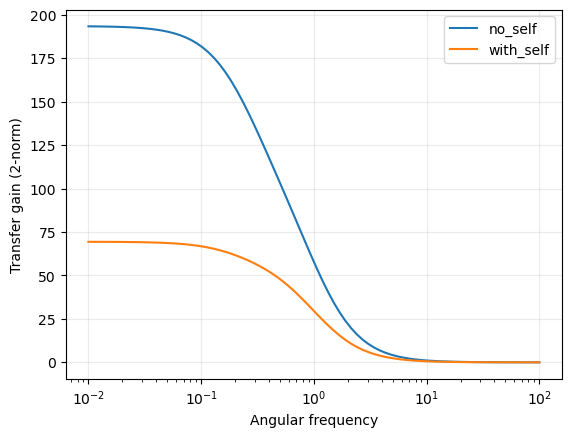

In [4]:
frequency = comparison['frequency_curves']
for variant, table in frequency.groupby('variant'):
    plt.semilogx(table['omega'], table['gain_2norm'], label=variant)
plt.xlabel('Angular frequency')
plt.ylabel('Transfer gain (2-norm)')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Save comparison tables

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
comparison['summary'].to_csv(OUTPUT_DIR / 'summary.csv', index=False)
comparison['top_path_scores'].to_csv(OUTPUT_DIR / 'top_path_scores.csv', index=False)
comparison['top_controllability_scores'].to_csv(OUTPUT_DIR / 'top_controllability_scores.csv', index=False)
comparison['frequency_curves'].to_csv(OUTPUT_DIR / 'frequency_curves.csv', index=False)
print(f'Saved comparison tables to {OUTPUT_DIR.resolve()}')

Saved comparison tables to C:\Users\ranic\Documents\GitHub\schur_decomp\outputs\network_linear_systems\self_comparison
